# Multi-Model Switching with Contact

**RQ2 handover.** What does the state transfer cost when the two models use
different representations?

Three backends behind one interface — FEM, OpenSim, and an FMU — switched by an
ordered region map on the pendulum angle, against a monolithic OpenModelica
reference. This is the notebook that measures the handover itself: every
committed transfer carries a report, and the quantities that the canonical
interface does *not* carry are the ones that price it.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().resolve()))
from evidence import repo_root

REPO = repo_root()

import evidence as ev
from plot_setup import FULL_WIDTH, set_professional_style
from record import record, paper_results_dir

plt = set_professional_style(latex=True)

# Recorded numbers belong to the paper repository, not to this one.
RESULTS, _results_source = paper_results_dir(REPO)
print(f"repository root resolved: {REPO.name}")
print(f"results destination      : {_results_source}")

repository root resolved: SystemSimulation
results destination      : sibling SysSimX-Framework-Paper checkout


In [2]:
# Pin the OpenModelica toolchain. OMPython resolves omc through OPENMODELICAHOME
# and PATH, so a second installation silently changes which compiler builds the
# reference - and therefore the trajectory every error below is measured against.
import os

OM_VERSION_EXPECTED = "1.26.3"
OM_HOME = Path(os.environ.get("SYSSIMX_OM_HOME", r"C:\Program Files\OpenModelica1.26.3-64bit"))
if next((c for c in (OM_HOME / "bin/omc.exe", OM_HOME / "bin/omc") if c.is_file()), None) is None:
    raise FileNotFoundError(f"No OpenModelica compiler under {OM_HOME}. Set SYSSIMX_OM_HOME.")
os.environ["OPENMODELICAHOME"] = str(OM_HOME)

from OMPython import OMCSessionZMQ

om_version = OMCSessionZMQ().sendExpression("getVersion()")
print(f"OpenModelica : {om_version}")
if OM_VERSION_EXPECTED not in om_version:
    raise RuntimeError(
        f"Expected OpenModelica {OM_VERSION_EXPECTED}, got {om_version}. The reference is only "
        f"comparable within one toolchain: set SYSSIMX_OM_HOME and OM_VERSION_EXPECTED together."
    )

OpenModelica : OpenModelica v1.26.3 (64-bit)


## Configuration

The scenario is the shared contact configuration. The launch gate is what keeps
the expensive deformable model out of the window where the pendulum is
accelerating away from the wall and cannot contact anything.

In [3]:
# CONTACT_SCENARIO's tol_time is 1.5e-4, chosen for the *performance* notebook:
# it sits above the FEM's own 1e-4 s contact sub-step so `_locate_event_time`
# accepts the bracket the FEM already reported and skips bisection, at about
# four fewer FEM solves per event. That trade is right when the quantity is
# time. Here the quantity is agreement with the reference, and repeated impacts
# amplify sub-millisecond timing differences (issues.md EVID-03): at 1.5e-4 this
# run located 3 of the reference's 5 contacts, with two of them ~37 ms adrift.
SCENARIO = ev.CONTACT_SCENARIO.replace(event_tol_time=1e-5)
OUT_DIR = REPO / "notebooks" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PACKAGE = REPO / "demos" / "ControlledPendulum" / "src" / "modelica" / "ControlledPendulum"
REFERENCE_MODEL = "ControlledPendulum.Examples.Contact.RigidContact"
FMU_PATHS = ev.discover_fmus(REPO, sys.platform)

display(pd.Series(SCENARIO.provenance()).to_frame("value"))

,value
name,contact
contact,True
t0,0.0
t_end,0.4
macro_dt,0.001
fem_internal_dt,0.001
switch_threshold_rad,0.075
switch_band_rad,0.005
region_modes,"[FEM, FMU]"
gate_t_open_s,0.03


## Monolithic reference

In [4]:
from OMPython import ModelicaSystem

reference = ModelicaSystem(
    fileName=str(PACKAGE / "package.mo"), modelName=REFERENCE_MODEL, omhome=str(OM_HOME)
)
reference.setParameters({"useReset": "true"})
reference.buildModel()
reference.simulate()

REF_SIGNALS = ("time", "theta", "theta_ref", "u_control", "pid.I_out", "pendulum.contact")
ref = {name: reference.getSolutions(name).flatten() for name in REF_SIGNALS}

# Reference contact instants are the *rising edges* of the contact flag, not
# every second sample of it: the flag stays high for the whole contact phase, so
# a fixed stride silently mislabels the events it pairs up.
flag = np.asarray(ref["pendulum.contact"]) > 0
edges = np.flatnonzero(np.diff(flag.astype(int)) == 1) + 1
ref_contact_times = ref["time"][edges]
ref_contact_times = ref_contact_times[ref_contact_times <= SCENARIO.t_end]
print(f"reference contacts within the horizon: {len(ref_contact_times)}")

[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").
[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


reference contacts within the horizon: 5


## Plant

`MasterPendulum` builds all three backends and owns its region map. Only the
region *key* is overridden, to add the launch gate; the gate reads the active
sub-model's clock because `HybridAlgorithm` calls `_do_step_internal` directly
for trial steps and bisection, which never advances the wrapper's own `t`.

In [5]:
from syssimx_examples.controlled_pendulum import MasterPendulum

REGION_GATE = ev.TimeGatedRegionKey(
    offset=SCENARIO.gate_offset_rad, t_open=SCENARIO.gate_t_open_s
)


class GatedMasterPendulum(MasterPendulum):
    '''`MasterPendulum` whose region key is gated through the launch window.'''

    @staticmethod
    def _absolute_theta(component):
        return REGION_GATE(component)


plant = GatedMasterPendulum(name="MasterPendulum", initial_mode="FMU")
plant.record_switch_state = True
plant.set_parameters(**{"FEM": ev.make_fem_parameters(SCENARIO)})

system, plant = ev.assemble_system(
    plant, SCENARIO, FMU_PATHS, case_name="Multi-Model Switching"
)

initial_mode = plant.active_mode
print(f"declared initial mode : FMU")
print(f"reconciled region     : {plant.active_region_index} ({initial_mode})")

declared initial mode : FMU
reconciled region     : 2 (FMU)


## Run

In [6]:
with tqdm(total=SCENARIO.sim_time, desc="simulation", unit=" sim s") as bar:
    seen = SCENARIO.t0

    def advance(t_now, _t_final):
        global seen
        now = min(max(t_now, SCENARIO.t0), SCENARIO.t_end)
        bar.update(now - seen)
        seen = now

    system.run(SCENARIO.t0, SCENARIO.t_end, SCENARIO.macro_dt, progress=advance)

history = system.get_history()
t_plant, data_plant = history[plant.name]
t_plant = np.asarray(t_plant, dtype=float)
theta_plant = np.asarray(data_plant["theta"], dtype=float)

contact_times = ev.contact_event_times(system, plant)
intervals = ev.mode_intervals(plant.switch_events, initial_mode, SCENARIO.t0, SCENARIO.t_end)

n_compared = min(len(contact_times), len(ref_contact_times))
contact_delta = np.asarray(contact_times[:n_compared]) - np.asarray(ref_contact_times[:n_compared])

print(f"switches dispatched : {len(plant.switch_events)}")
print(f"contacts  syssimx {len(contact_times)}  reference {len(ref_contact_times)}")
# Divergence is checked hard, before record(), further down.

simulation:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

switches dispatched : 6
contacts  syssimx 5  reference 5


## T1 — per-switch transfer report

Two groups of quantities, read differently.

`theta`, `omega` and `tau` are **enforced** invariants: the transaction raises
and rolls back when any of them jumps further than its tolerance, so a completed
run cannot show a violation. Their columns confirm the contract held; they are
not a measurement of handover quality.

`alpha` and the energy terms are **measured but not enforced**, because the
canonical interface carries angular position, velocity and torque only. Those are
the quantities that actually price a handover. `elastic_lost` is the strain
energy present in the FEM state and absent from the rigid target — the projection
loss of leaving the deformable model.

In [7]:
rows = []
for event in plant.switch_events:
    report = event.transfer_report
    rows.append({
        "t": float(event.time),
        "from": event.from_mode,
        "to": event.to_mode,
        "d_theta": report.theta_error,
        "d_omega": report.omega_error,
        "d_tau": report.tau_error,
        "d_alpha": report.alpha_error,
        "d_energy": report.energy_error,
        "elastic_lost": report.elastic_energy_lost,
        "lost": ", ".join(
            n for n in report.semantics.lost if n in ("theta", "omega", "alpha", "tau")
        ) or "-",
        "violations": ", ".join(report.violations(plant.transfer_tolerances)) or "-",
    })

transfers = pd.DataFrame(rows)
fmt = {c: "{:.3e}" for c in
       ("d_theta", "d_omega", "d_tau", "d_alpha", "d_energy", "elastic_lost")}
display(transfers.style.format({"t": "{:.6f}", **fmt}).hide(axis="index"))

assert not (transfers["violations"] != "-").any(), "a transfer violated its declared tolerance"
print(f"{len(transfers)} transfers, no contract violation")
print(f"max |d_alpha|       : {transfers['d_alpha'].abs().max():.3e} rad/s^2  (not enforced)")
print(f"max elastic_lost    : {transfers['elastic_lost'].max():.3e} J  (leaving FEM)")

t,from,to,d_theta,d_omega,d_tau,d_alpha,d_energy,elastic_lost,lost,violations
0.010164,FMU,OpenSim,0.000e+00,0.000e+00,0.000e+00,1.137e-13,0.000e+00,0.000e+00,alpha,-
0.052055,OpenSim,FMU,0.000e+00,0.000e+00,0.000e+00,5.684e-14,0.000e+00,0.000e+00,alpha,-
0.132539,FMU,OpenSim,0.000e+00,0.000e+00,0.000e+00,5.684e-14,0.000e+00,0.000e+00,alpha,-
0.161711,OpenSim,FEM,9.714e-17,9.770e-15,1.776e-15,0.000e+00,3.109e-15,-6.612e-19,alpha,-
0.350797,FEM,OpenSim,0.000e+00,0.000e+00,0.000e+00,3.981e-05,0.000e+00,5.972e-07,alpha,-
0.385297,OpenSim,FMU,0.000e+00,0.000e+00,0.000e+00,1.137e-13,0.000e+00,0.000e+00,alpha,-


6 transfers, no contract violation
max |d_alpha|       : 3.981e-05 rad/s^2  (not enforced)
max elastic_lost    : 5.972e-07 J  (leaving FEM)


## Boundary localization

Each boundary is a Schmitt trigger armed at the far edge of its band, so a
located crossing sits on `breakpoint + band` when the key rises and on
`breakpoint - band` when it falls, never on the breakpoint itself. `residual` is
the distance from that armed edge; measuring against the nominal breakpoint
would report the band width and say nothing about localization.

`off_grid` is the distance to the nearest communication point. A value near zero
would mean the switch merely landed on a step boundary.

In [8]:
abs_theta = np.abs(theta_plant)
boundaries = plant.switch_regions.boundaries
event_history = history["Events"]

rows = []
for (_comp, event_name), records in event_history.items():
    if not event_name.startswith("region_boundary_"):
        continue
    boundary = boundaries[int(event_name.rsplit("_", 1)[1])]
    for rec in records:
        t_event = float(rec.t)
        # The key is the gated signal, not abs(theta): before gate_t_open_s the
        # two differ by the decaying offset, and the armed threshold is compared
        # against the key the algorithm actually saw.
        key = REGION_GATE.value(t_event, float(np.interp(t_event, t_plant, abs_theta)))
        armed = (boundary.upper_threshold if key >= boundary.breakpoint
                 else boundary.lower_threshold)
        committed = [e for e in plant.switch_events if abs(e.time - t_event) <= 1e-12]
        rows.append({
            "t": t_event,
            "boundary": event_name,
            "armed": armed,
            "key": key,
            "residual": key - armed,
            "off_grid": ev.distance_to_grid(t_event, SCENARIO.macro_dt),
            "switch": (f"{committed[0].from_mode} -> {committed[0].to_mode}"
                       if committed else "-"),
        })

localization = pd.DataFrame(rows).sort_values("t").reset_index(drop=True)
display(localization.style.format({
    "t": "{:.6f}", "armed": "{:.6f}", "key": "{:.6f}",
    "residual": "{:.3e}", "off_grid": "{:.3e}",
}).hide(axis="index"))

print(f"max |residual|      : {localization['residual'].abs().max():.3e} rad")
print(f"min off-grid offset : {localization['off_grid'].min():.3e} s "
      f"(macro step {SCENARIO.macro_dt:.1e} s)")

t,boundary,armed,key,residual,off_grid,switch
0.010164,region_boundary_1,0.244346,0.244291,-5.472e-05,1.641e-04,FMU -> OpenSim
0.052055,region_boundary_1,0.279253,0.279279,2.615e-05,5.469e-05,OpenSim -> FMU
0.132539,region_boundary_1,0.244346,0.244366,1.974e-05,4.609e-04,FMU -> OpenSim
0.161711,region_boundary_0,0.070000,0.070052,5.163e-05,2.891e-04,OpenSim -> FEM
0.350797,region_boundary_0,0.080000,0.080036,3.620e-05,2.031e-04,FEM -> OpenSim
0.385297,region_boundary_1,0.279253,0.279252,-3.010e-07,2.969e-04,OpenSim -> FMU


max |residual|      : 5.472e-05 rad
min off-grid offset : 5.469e-05 s (macro step 1.0e-03 s)


In [9]:
# --- gate on the contact sequence ------------------------------------------
# The transfer report above stands on its own: it measures the handover, not the
# reference. Everything that *compares* against the monolithic run is meaningless
# once the two are on different bounce sequences, and by the convention in
# results/README.md a file without the .smoke suffix is quotable. So a diverged
# run must not reach record().
n_sys, n_ref = len(contact_times), len(ref_contact_times)
_gaps = np.diff(ref_contact_times)
_mean_interval = float(np.mean(_gaps)) if _gaps.size else float("inf")
_max_delta = float(np.abs(contact_delta).max()) if contact_delta.size else 0.0

print(f"contacts          : {n_sys} located, {n_ref} in the reference")
print(f"mean bounce gap   : {_mean_interval:.4f} s")
print(f"max |delta|       : {_max_delta:.3e} s ({_max_delta / _mean_interval:.1%} of a gap)")

if n_sys != n_ref:
    raise AssertionError(
        f"Contact sequences diverged: {n_sys} located against {n_ref} in the reference. "
        f"The comparison metrics below would pair events that do not correspond. "
        f"tol_time is {SCENARIO.event_tol_time:.1e} s; a coarser localization is the "
        f"first thing to check."
    )

# A quarter of a bounce interval is already a different sequence for any use the
# paper makes of it. The pre-refactor run at tol_time = 1e-5 sat at 2.1e-3 s,
# about 5 % of a gap, so this leaves ample room for an honest run.
if _max_delta > 0.25 * _mean_interval:
    raise AssertionError(
        f"Contact instants differ by up to {_max_delta:.3e} s, more than a quarter of the "
        f"mean bounce interval {_mean_interval:.3e} s. The runs resolve the same number of "
        f"contacts but not at the same times, so the theta error is dominated by that phase "
        f"shift rather than by model fidelity."
    )

print("OK: same contact count, instants within a quarter interval.")

theta_metrics = ev.trajectory_error_metrics(t_plant, theta_plant, ref["time"], ref["theta"])

record(
    "T1",
    {
        "transfers": transfers.drop(columns=["lost", "violations"]).to_dict("list"),
        "n_switches": int(len(transfers)),
        "max_abs_d_alpha": float(transfers["d_alpha"].abs().max()),
        "max_elastic_lost": float(transfers["elastic_lost"].max()),
        "any_violation": False,
        "localization": localization.drop(columns=["boundary", "switch"]).to_dict("list"),
        "max_abs_residual_rad": float(localization["residual"].abs().max()),
        "min_off_grid_s": float(localization["off_grid"].min()),
        "theta_error_vs_reference": theta_metrics,
        "contact_time_delta_s": [float(v) for v in contact_delta],
        "n_contacts": {"syssimx": len(contact_times), "reference": len(ref_contact_times)},
        "openmodelica": om_version,
        "scenario": SCENARIO.provenance(),
    },
    directory=RESULTS,
    notebook="03_switching",
    smoke=False,
)

contacts          : 5 located, 5 in the reference
mean bounce gap   : 0.0390 s
max |delta|       : 2.083e-03 s (5.3% of a gap)
OK: same contact count, instants within a quarter interval.


WindowsPath('C:/Users/flori/source/repos/FlorianFrech/SysSimX-Framework-Paper/results/T1.json')

## F3 - the switched trajectory

Two figures. Both plot the same two things: the monolithic OpenModelica solution
of the rigid pendulum with ideal elastic contact, and the co-simulated
trajectory.

**F3a, the whole horizon.** The co-simulated line is coloured by the model that
was active, so a colour change *is* a switch and nothing else has to mark it.
The reference is the grey rail underneath; where the coloured line sits on it,
the switched run and the monolithic solution agree.

**F3b, the contact window, FEM only.** The FMU and OpenSim segments are dropped.
During the bounces the deformable model is the active one, and the question is
whether it follows the rigid reference through the impact sequence.


In [10]:
from plot_setup import GRID_STYLE, MODEL_COLORS, REFERENCE_STYLE, WALL_STYLE

# The detail window is derived from the located contacts, not fixed: it is the
# bounce sequence plus a small margin. A hand-set window either clips the last
# bounces or includes the approach, whose amplitude is an order larger and
# flattens everything the figure exists to show.
if contact_times:
    _span = max(contact_times[-1] - contact_times[0], 5 * SCENARIO.macro_dt)
    WINDOW = (contact_times[0] - 0.08 * _span, contact_times[-1] + 0.12 * _span)
else:
    WINDOW = (SCENARIO.t0, SCENARIO.t_end)
print(f"detail window: {WINDOW[0]:.4f} .. {WINDOW[1]:.4f} s "
      f"({len(contact_times)} contacts)")


def mode_segments(times, values, mode_intervals):
    """Split a trajectory into (mode, t, y) pieces, one per active interval.

    The last sample of one piece is repeated as the first of the next so the
    coloured segments join without a visible gap at the switch.
    """
    times = np.asarray(times, dtype=float)
    values = np.asarray(values, dtype=float)
    for left, right, mode in mode_intervals:
        inside = (times >= left) & (times <= right)
        if inside.sum() < 2:
            continue
        yield mode, times[inside], values[inside]


detail window: 0.1598 .. 0.3490 s (5 contacts)


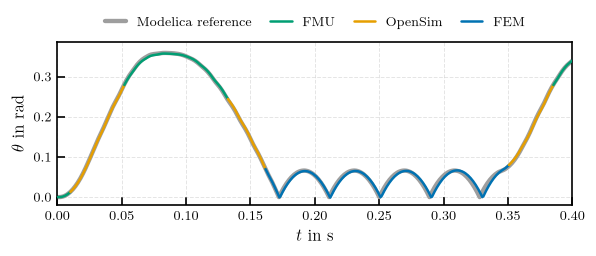

In [11]:
# F3a - the whole horizon. The trajectory itself is coloured by the model that
# was active, so the switches need no separate marking, and the grey rail
# underneath is the monolithic reference.
fig, ax = plt.subplots(figsize=(0.86 * FULL_WIDTH, 0.38 * FULL_WIDTH))

ax.plot(ref["time"], ref["theta"], label="Modelica reference", **REFERENCE_STYLE)

drawn = set()
for mode, t_seg, y_seg in mode_segments(t_plant, theta_plant, intervals):
    ax.plot(t_seg, y_seg, color=MODEL_COLORS[mode], linewidth=1.5, solid_capstyle="round",
            zorder=3, label=mode if mode not in drawn else None)
    drawn.add(mode)

ax.set_xlim(SCENARIO.t0, SCENARIO.t_end)
ax.set_xlabel(r"$t$ in $\mathrm{s}$")
ax.set_ylabel(r"$\theta$ in $\mathrm{rad}$")
ax.grid(True, **GRID_STYLE)
# Above the axes: at this aspect ratio any in-axes corner collides with either
# the launch ramp or the bounce envelope.
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=4, fontsize=8,
          frameon=False, handlelength=1.6, columnspacing=1.4)

fig.tight_layout()
fig.savefig(OUT_DIR / "F3a_trajectory.pdf", bbox_inches="tight")
plt.show()


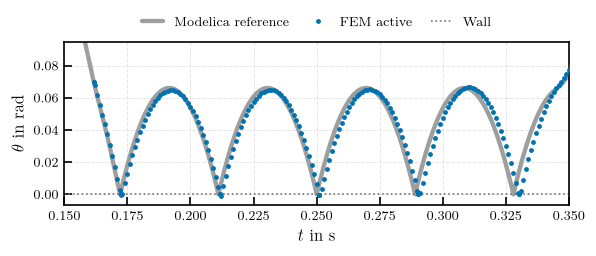

In [12]:
# F3b - the contact window, FEM only. Everything outside the FEM intervals is
# dropped: during the bounces the deformable model is the active one, and the
# question this figure answers is whether it tracks the rigid reference with
# ideal elastic contact through the impact sequence.
fig, ax = plt.subplots(figsize=(0.86 * FULL_WIDTH, 0.38 * FULL_WIDTH))

ax.plot(ref["time"], ref["theta"], label="Modelica reference", **REFERENCE_STYLE)

fem_intervals = [iv for iv in intervals if iv[2] == "FEM"]
drawn = False
for mode, t_seg, y_seg in mode_segments(t_plant, theta_plant, fem_intervals):
    ax.plot(t_seg, y_seg, color=MODEL_COLORS["FEM"], linestyle="None", marker="o", markersize=2, zorder=3, label=None if drawn else "FEM active")
    drawn = True

ax.axhline(0.0, label="Wall", **WALL_STYLE)

ax.set_xlim(0.15, 0.35)
# Scaled to the bounce envelope inside the window, so the impacts fill the axes.
inside = (t_plant >= WINDOW[0]) & (t_plant <= WINDOW[1])
top = float(np.max(theta_plant[inside])) if inside.any() else 0.05
ax.set_ylim(-0.08 * top, 1.15 * top)
ax.set_xlabel(r"$t$ in $\mathrm{s}$")
ax.set_ylabel(r"$\theta$ in $\mathrm{rad}$")
ax.grid(True, **GRID_STYLE)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=3, fontsize=8,
          frameon=False, handlelength=1.6, columnspacing=1.4)

fig.tight_layout()
fig.savefig(OUT_DIR / "F3b_contact_window.pdf", bbox_inches="tight")
plt.show()


## Reading the result

**The enforced columns are a contract check, not a quality measure.** They cannot
show a violation in a run that completed, because the transaction would have
rolled back instead.

**The unenforced columns are the result.** `d_alpha` and `elastic_lost` are what
the canonical interface cannot carry: acceleration is not part of it, and the
strain energy in the FEM state has no counterpart in a rigid model. That loss is
by design, and this table is where its size is stated.

**Placement is off-grid by construction.** Read `min off_grid` against the macro
step: the switches sit strictly between communication points, which is what
separates this from switching on the grid.

The trajectory error against the monolithic reference is *not* a placement
measurement — the reference never switches, so it mixes model mismatch with
placement. `05_placement.ipynb` isolates placement against a refined reference of
the same configuration.